In [30]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
import glob
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset

RANDOM_SEED = 1

## 1. Summurazition of the data files with a LLM

In [32]:
def summarize_text(text):
    """
        Text file summarization function.
        This function takes a text file as input and returns a summary of the text.
    """
    return text[:min(100, len(text))] + '...'

## 2. Load the data and get summary

In [33]:
def load_data(data_dir):
    data = []
    file_paths = glob.glob(os.path.join(data_dir, "*.txt"))
    for file in file_paths:
        with open(file, "r", encoding="utf-8") as f:
            text = f.read()
        summary = summarize_text(text)
        data.append((text, summary))
    return data

In [ ]:
data_dir = "./data/datasets/test/"
data = load_data(data_dir)

print("Number of samples:", len(data))

Number of samples: 31


In [35]:
class SummarizationDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        orig, summ = self.data[idx]
        return orig, summ

## 3. Split dataset in train, test and validation

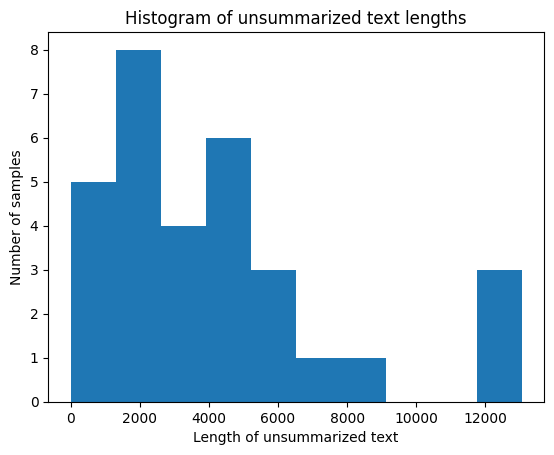

In [36]:

# --- Stratify the data based on unsummarized text length ---
# We compute the length of each unsummarized text and bin it into discrete bins.
lengths = np.array([len(x[0]) for x in data])
num_bins = 10
bins = np.linspace(lengths.min(), lengths.max(), num_bins)
binned_lengths = np.digitize(lengths, bins)

# Ensure no bin has < 2 samples
unique, counts = np.unique(binned_lengths, return_counts=True)
valid_bins = {u for u, c in zip(unique, counts) if c >= 2}

# Merge rare bins
for i in range(len(binned_lengths)):
    if binned_lengths[i] not in valid_bins:
        binned_lengths[i] = min(valid_bins, key=lambda x: abs(x - binned_lengths[i]))  # Merge to nearest


# plot histogram of lengths
import matplotlib.pyplot as plt
plt.hist(lengths, bins=num_bins)
plt.xlabel("Length of unsummarized text")
plt.ylabel("Number of samples")
plt.title("Histogram of unsummarized text lengths")
plt.show()


In [37]:

train_data, temp_data, train_strata, temp_strata = train_test_split(
    data, binned_lengths, test_size=0.4, random_state=RANDOM_SEED, stratify=binned_lengths
)

val_data, test_data, _, _ = train_test_split(
    temp_data, temp_strata, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_strata
)

train_dataset = SummarizationDataset(train_data)
val_dataset   = SummarizationDataset(val_data)
test_dataset  = SummarizationDataset(test_data)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 18
Validation size: 6
Test size: 7


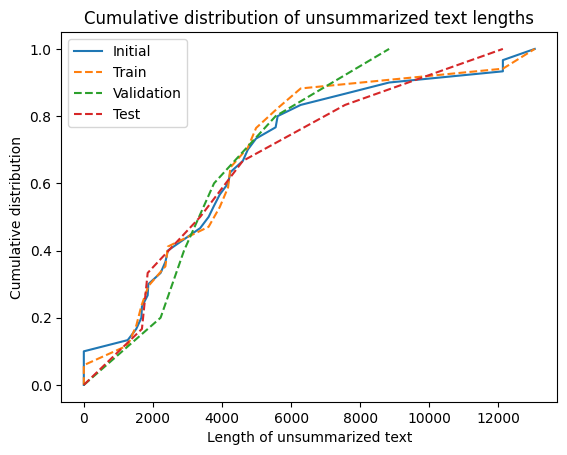

In [38]:
# plot repartition of lengths in train, val and test (should be similar, don't use histograms)
train_lengths = np.array([len(x[0]) for x in train_data])
val_lengths = np.array([len(x[0]) for x in val_data])
test_lengths = np.array([len(x[0]) for x in test_data])
initial_lengths = np.array([len(x[0]) for x in data])

plt.plot(np.sort(initial_lengths), np.linspace(0, 1, len(initial_lengths)), label="Initial")
plt.plot(np.sort(train_lengths), np.linspace(0, 1, len(train_lengths)), label="Train", linestyle="--")
plt.plot(np.sort(val_lengths), np.linspace(0, 1, len(val_lengths)), label="Validation", linestyle="--")
plt.plot(np.sort(test_lengths), np.linspace(0, 1, len(test_lengths)), label="Test", linestyle="--")
plt.xlabel("Length of unsummarized text")
plt.ylabel("Cumulative distribution")
plt.title("Cumulative distribution of unsummarized text lengths")
plt.legend()
plt.show()